# Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, classification_report

import warnings
warnings.filterwarnings('ignore')

# Create a classification dataset

In [2]:
X, y = make_classification(
    n_samples=200,      # number of samples
    n_features=2,       # two input features (A and B)
    n_informative=2,    # both are informative
    n_redundant=0,      # no redundant features
    n_clusters_per_class=2,  # more than one cluster per class (adds non-linearity)
    class_sep=0.8,      # controls how mixed the classes are (lower = harder, more non-linear)
    random_state=42
)

In [3]:
# Convert to DataFrame
df = pd.DataFrame(X, columns=["A", "B"])
df["Class"] = y

In [4]:
df.head()

,A,B,Class
0,1.489767,-1.208241,1
1,1.330287,-1.259848,1
2,-0.975042,-1.247633,0
3,-2.385395,0.763532,0
4,1.172246,0.640695,1


In [5]:
df.Class.unique()

array([1, 0])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       200 non-null    float64
 1   B       200 non-null    float64
 2   Class   200 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 4.8 KB


# Check for non-linear relationship

## Scatter Plot

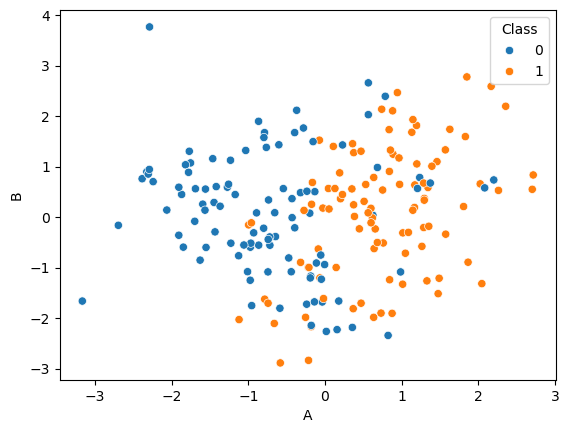

In [7]:
sns.scatterplot(data=df, x='A', y='B', hue='Class');

* No clear linear relationship

## Correlation

In [8]:
df.corr()

,A,B,Class
A,1.000000,0.107137,0.626555
B,0.107137,1.000000,-0.002445
Class,0.626555,-0.002445,1.000000


# Train Test Split

In [9]:
X = df.drop('Class', axis=1)
y = df['Class']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((160, 2), (40, 2), (160,), (40,))

# Logistic Regression

## Without Polynomial Features

In [12]:
clf_wo_poly = LogisticRegression()

### Fit the model

In [13]:
clf_wo_poly.fit(X_train, y_train)

LogisticRegression()

### Prediction on test data

In [14]:
y_pred_wo_poly = clf_wo_poly.predict(X_test)

### Classification Report

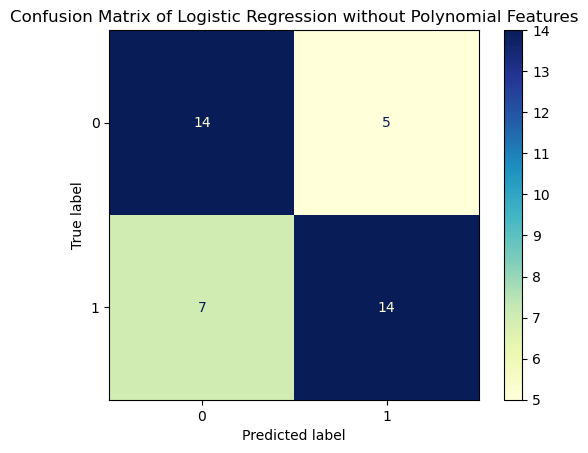

In [15]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_wo_poly), display_labels=clf_wo_poly.classes_)
disp.plot(cmap="YlGnBu")
plt.title("Confusion Matrix of Logistic Regression without Polynomial Features")
plt.show()

In [16]:
print('Classification Report for Logistic Regression model without Polynomial Features\n')
print(classification_report(y_test, y_pred_wo_poly))

Classification Report for Logistic Regression model without Polynomial Features

              precision    recall  f1-score   support

           0       0.67      0.74      0.70        19
           1       0.74      0.67      0.70        21

    accuracy                           0.70        40
   macro avg       0.70      0.70      0.70        40
weighted avg       0.70      0.70      0.70        40



### Decision Boundary

<Axes: >

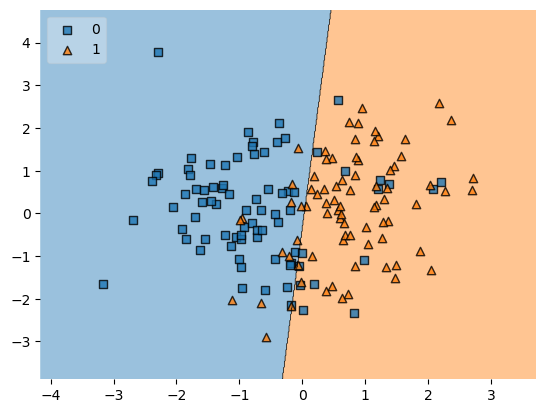

In [17]:
plot_decision_regions(X_train.values, y_train.values, clf_wo_poly, legend=2)

## With Polynomial Features

In [18]:
clf_w_poly = LogisticRegression()

In [19]:
poly_transform = PolynomialFeatures(degree=3, include_bias=False)

In [20]:
X_train_poly = poly_transform.fit_transform(X_train)
X_test_poly = poly_transform.transform(X_test)

### Fit the model

In [21]:
clf_w_poly.fit(X_train_poly, y_train)

LogisticRegression()

### Prediction on test data

In [22]:
y_pred_w_poly = clf_w_poly.predict(X_test_poly)

### Classification Report

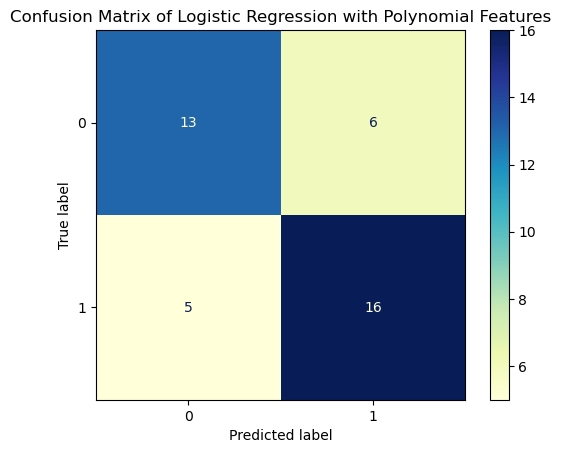

In [23]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_w_poly), display_labels=clf_w_poly.classes_)
disp.plot(cmap="YlGnBu")
plt.title("Confusion Matrix of Logistic Regression with Polynomial Features")
plt.show()

In [24]:
print('Classification Report for Logistic Regression model with Polynomial Features\n')
print(classification_report(y_test, y_pred_w_poly))

Classification Report for Logistic Regression model with Polynomial Features

              precision    recall  f1-score   support

           0       0.72      0.68      0.70        19
           1       0.73      0.76      0.74        21

    accuracy                           0.72        40
   macro avg       0.72      0.72      0.72        40
weighted avg       0.72      0.72      0.72        40



* Note the increase in accuracy and other scores.

In [25]:
print(f'Cross Validated Accuracy score: ', np.mean(cross_val_score(clf_w_poly, poly_transform.fit_transform(X), y, scoring='accuracy', cv=10, n_jobs=-1)))

Cross Validated Accuracy score:  0.8100000000000002


### Decision Boundary

In [26]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [27]:
def plot_decision_boundary(X,y,degree=1):
    
    poly = PolynomialFeatures(degree=degree)
    X_trf = poly.fit_transform(X)
    
    clf = LogisticRegression()
    clf.fit(X_trf, y)
    
    accuracy = np.mean(cross_val_score(clf,X_trf,y,scoring='accuracy',cv=10))
    
    a=np.arange(start=X[:,0].min()-1, stop=X[:,0].max()+1, step=0.01)
    b=np.arange(start=X[:,1].min()-1, stop=X[:,1].max()+1, step=0.01)


    XX,YY=np.meshgrid(a,b)
    
    input_array=np.array([XX.ravel(),YY.ravel()]).T

    labels=clf.predict(poly.transform(input_array))
    
    plt.contourf(XX,YY,labels.reshape(XX.shape),alpha=0.5)
    plt.scatter(X[:,0],X[:,1], c=y)
    plt.title('Degree = {}, accuracy is {}'.format(degree,np.round(accuracy,4)))

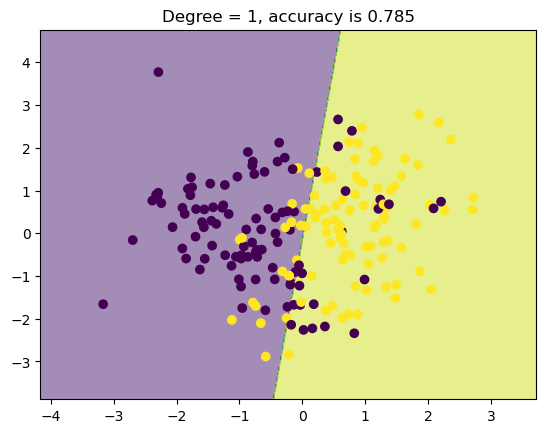

In [28]:
plot_decision_boundary(X, y)

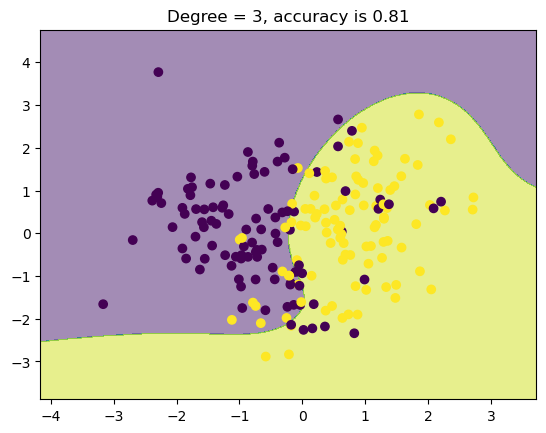

In [29]:
plot_decision_boundary(X,y,degree=3)

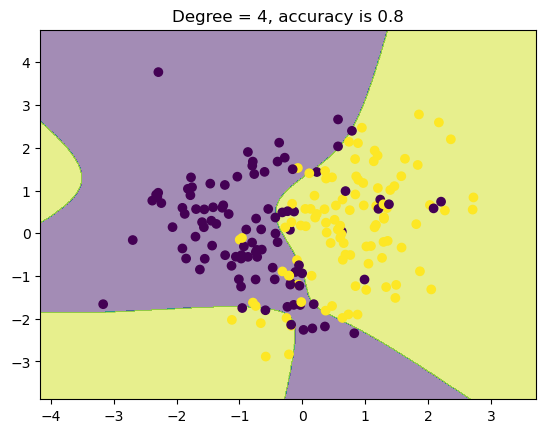

In [30]:
plot_decision_boundary(X,y,degree=4)

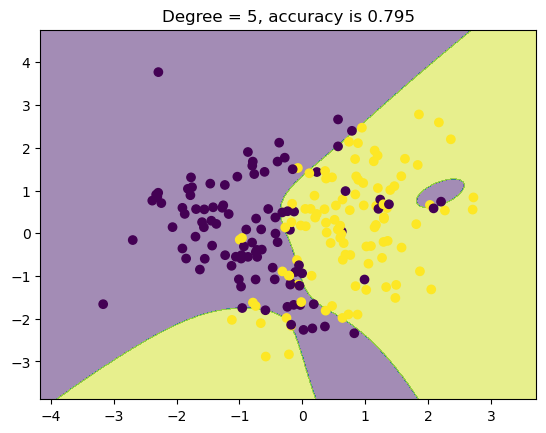

In [31]:
plot_decision_boundary(X,y,degree=5)

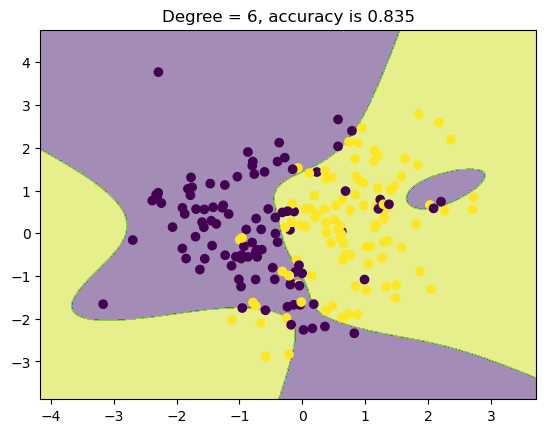

In [32]:
plot_decision_boundary(X,y,degree=6)

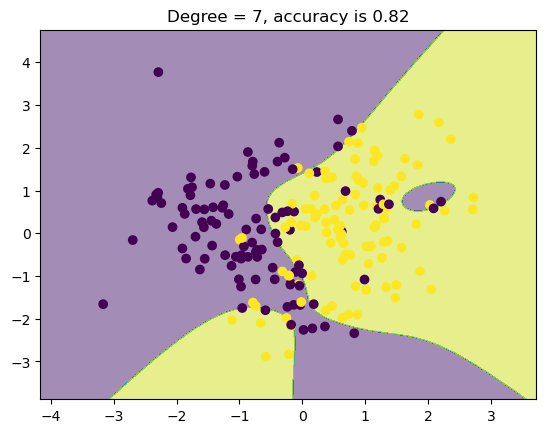

In [33]:
plot_decision_boundary(X,y,degree=7)

* The model is doing well when the degree is either 3, 6 or 7